In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import (
    ResNet18_Weights,
    MobileNet_V3_Small_Weights,
    EfficientNet_B0_Weights,
)
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
import random
import copy
import os
from pathlib import Path
from sklearn.decomposition import PCA

os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

random.seed(42)

Using device: cuda


## Task 1: Environment Setup and Data Loading

In [2]:
def load_images(n_per_class=10):
    """Load n images per class. Returns a list of (PIL.Image, label_string) tuples."""
    image_set = []
    
    for label in LABELS:
        class_dir = DATA_DIR / label
        paths = random.sample(list(class_dir.glob("*.jpg")), n_per_class)
        
        for path in paths:
            img = Image.open(path).convert("RGB")
            image_set.append((img, label))
    
    random.shuffle(image_set)
    return image_set

image_set = load_images(n_per_class=10)
print(f"Total images loaded: {len(image_set)}")

Total images loaded: 60


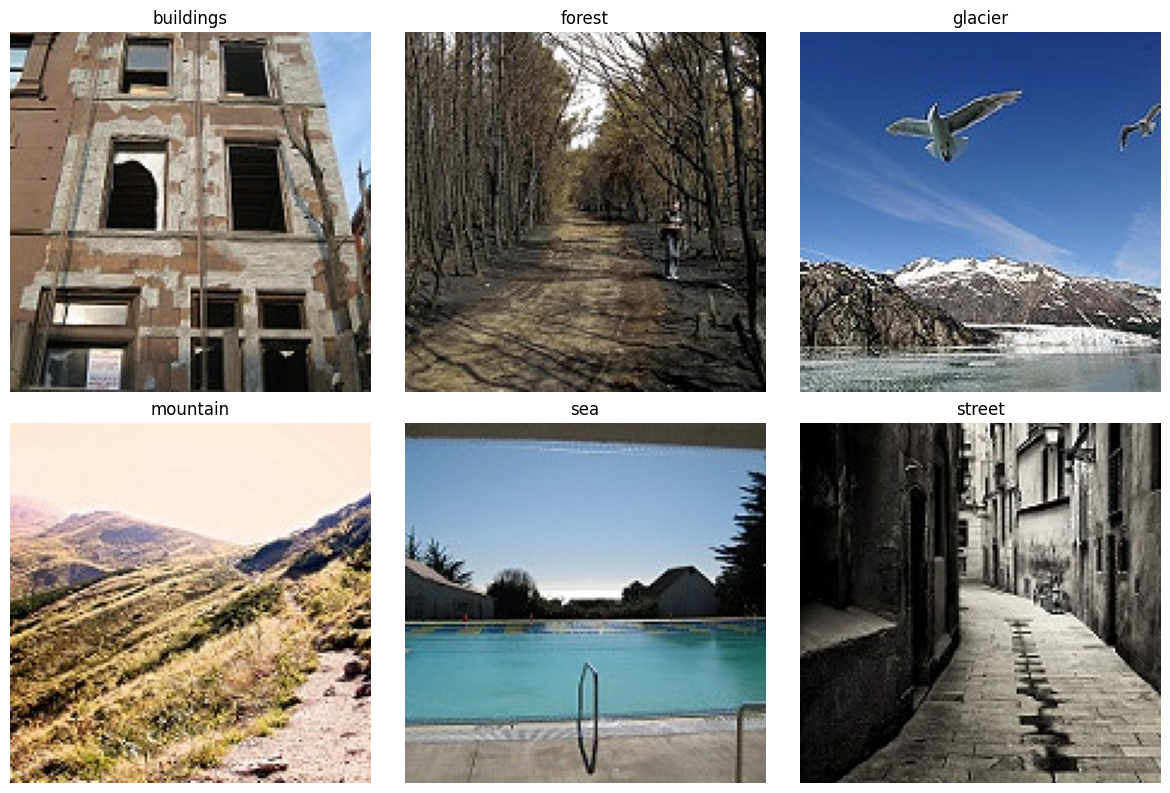

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, label in zip(axes.flatten(), LABELS):
    class_images = [img for img, true_label in image_set if true_label == label]
    ax.imshow(class_images[0])
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.savefig("outputs/dataset_sample.png")
plt.show()

# Comment:
# A pretrained ImageNet model is a reasonable starting point for this dataset.
# Even though ImageNet does not use the exact six labels here,
# the model has already learned useful visual features like edges, textures,
# shapes, buildings, water, roads, mountains, and trees.
# That makes it useful for transfer learning or feature extraction.

In [ ]:
print(os.path.exists("outputs/dataset_sample.png"))

In [4]:
print(os.path.exists("outputs/dataset_sample.png"))

True


## Task 2: Baseline Inference with ResNet18

In [5]:
resnet_weights = ResNet18_Weights.DEFAULT
resnet = models.resnet18(weights=resnet_weights).to(device).eval()
resnet_preproc = resnet_weights.transforms()
imagenet_classes = resnet_weights.meta["categories"]

print(f"ResNet18 parameters: {sum(p.numel() for p in resnet.parameters()):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s] 


ResNet18 parameters: 11,689,512


In [6]:
def run_inference(model, preprocess, image, device, class_labels, top_k=5):
    """
    Run inference on one PIL image and return top-k predictions.
    Returns a list of (class_name, probability) tuples.
    """
    input_tensor = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)

    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    top_probs, top_indices = torch.topk(probabilities, top_k)

    results = []
    for prob, index in zip(top_probs, top_indices):
        class_name = class_labels[index.item()]
        results.append((class_name, prob.item()))

    return results

In [7]:
resnet_results = []

for img, true_label in image_set:
    preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)
    resnet_results.append({
        "true_label": true_label,
        "top1_class": preds[0][0],
        "top1_prob": preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs": [p[1] for p in preds],
    })

print(f"Processed {len(resnet_results)} images.")

Processed 60 images.


In [ ]:
top1_probs = [r["top1_prob"] for r in resnet_results]

overall_mean = np.mean(top1_probs)
print(f"Overall mean top-1 probability: {overall_mean:.4f}")

print("\nMean top-1 probability by true class:")
for label in LABELS:
    class_probs = [r["top1_prob"] for r in resnet_results if r["true_label"] == label]
    print(f"{label:10s}: {np.mean(class_probs):.4f}")

In [ ]:
data_by_class = []

for label in LABELS:
    class_probs = [r["top1_prob"] for r in resnet_results if r["true_label"] == label]
    data_by_class.append(class_probs)

plt.figure(figsize=(10, 6))
plt.boxplot(data_by_class, labels=LABELS)
plt.title("ResNet18 Top-1 Confidence by True Class")
plt.xlabel("True Scene Class")
plt.ylabel("Top-1 Probability")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("outputs/resnet18_confidence_by_class.png")
plt.show()

# Comment:
# High confidence and high accuracy are not the same thing.
# A model can be confidently wrong.
# In a production image-tagging pipeline, I would use confidence scores as a warning system.
# If the top-1 probability is low, for example below 0.60, I would send the image to a human reviewer.
# If the probability is high, the system could accept the automatic prediction more safely.

In [8]:
print(os.path.exists("outputs/resnet18_confidence_by_class.png"))

False


In [9]:
import os

print("Files in outputs folder:")
print(os.listdir("outputs"))

Files in outputs folder:
['dataset_sample.png']


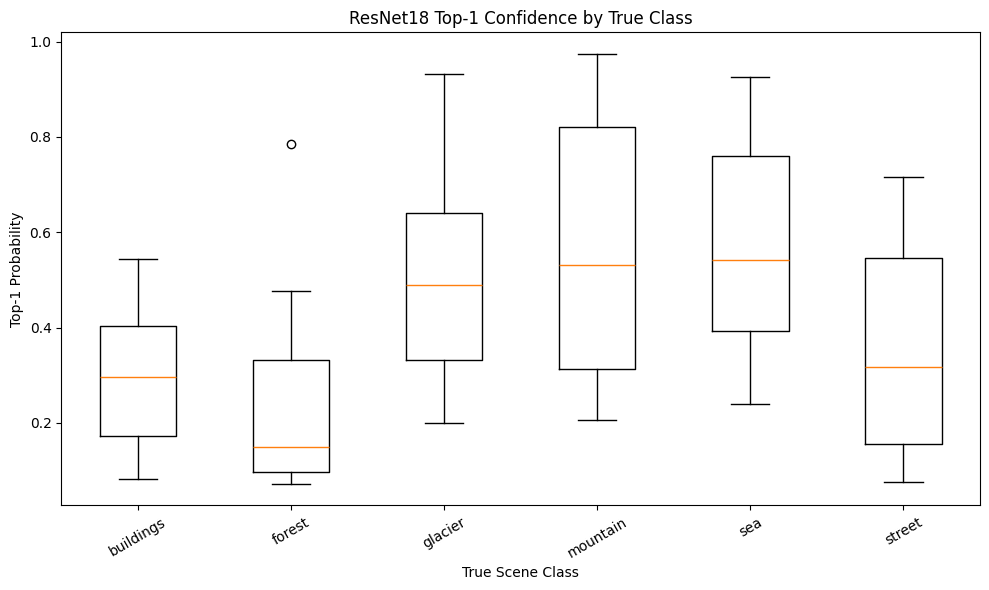

In [10]:
data_by_class = []

for label in LABELS:
    class_probs = [r["top1_prob"] for r in resnet_results if r["true_label"] == label]
    data_by_class.append(class_probs)

plt.figure(figsize=(10, 6))
plt.boxplot(data_by_class, tick_labels=LABELS)
plt.title("ResNet18 Top-1 Confidence by True Class")
plt.xlabel("True Scene Class")
plt.ylabel("Top-1 Probability")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("outputs/resnet18_confidence_by_class.png")
plt.show()

# Comment:
# High confidence and high accuracy are not the same thing.
# A model can be confidently wrong.
# In a production image-tagging pipeline, I would use confidence scores as a warning system.
# If the top-1 probability is low, for example below 0.60, I would send the image to a human reviewer.
# If the probability is high, the system could accept the automatic prediction more safely.

In [11]:
print(os.path.exists("outputs/resnet18_confidence_by_class.png"))
print(os.listdir("outputs"))

True
['resnet18_confidence_by_class.png', 'dataset_sample.png']


## Task 3: Multi-Model Comparison

In [1]:
# MobileNetV3-Small — designed for mobile and edge deployment
mobile_weights = MobileNet_V3_Small_Weights.DEFAULT
mobilenet = models.mobilenet_v3_small(weights=mobile_weights).to(device).eval()
mobile_preproc = mobile_weights.transforms()

# EfficientNet-B0 — designed to maximize accuracy per unit of compute
effnet_weights = EfficientNet_B0_Weights.DEFAULT
efficientnet = models.efficientnet_b0(weights=effnet_weights).to(device).eval()
effnet_preproc = effnet_weights.transforms()

# Print parameter counts for all three
for name, m in [
    ("ResNet18", resnet),
    ("MobileNetV3-Small", mobilenet),
    ("EfficientNet-B0", efficientnet),
]:
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:22s}  {params:>12,} parameters")

# Comment:
# A smaller parameter count means the model has fewer learned numbers.
# Smaller models usually run faster and use less memory.
# That is helpful for phones or edge devices.
# Larger models may have more capacity to learn complex patterns,
# but they can be slower and need more compute.

NameError: name 'MobileNet_V3_Small_Weights' is not defined

In [2]:
from torchvision.models import (
    ResNet18_Weights,
    MobileNet_V3_Small_Weights,
    EfficientNet_B0_Weights,
)

In [4]:
# MobileNetV3-Small — designed for mobile and edge deployment
mobile_weights = MobileNet_V3_Small_Weights.DEFAULT
mobilenet = models.mobilenet_v3_small(weights=mobile_weights).to(device).eval()
mobile_preproc = mobile_weights.transforms()

# EfficientNet-B0 — designed to maximize accuracy per unit of compute
effnet_weights = EfficientNet_B0_Weights.DEFAULT
efficientnet = models.efficientnet_b0(weights=effnet_weights).to(device).eval()
effnet_preproc = effnet_weights.transforms()

# Print parameter counts for all three
for name, m in [
    ("ResNet18", resnet),
    ("MobileNetV3-Small", mobilenet),
    ("EfficientNet-B0", efficientnet),
]:
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:22s}  {params:>12,} parameters")

# Comment:
# A smaller parameter count means the model has fewer learned numbers.
# Smaller models usually run faster and use less memory.
# That is helpful for phones or edge devices.
# Larger models may have more capacity to learn complex patterns,
# but they can be slower and need more compute.

NameError: name 'models' is not defined

In [10]:
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import (
    ResNet18_Weights,
    MobileNet_V3_Small_Weights,
    EfficientNet_B0_Weights,
)

In [11]:
resnet_weights = ResNet18_Weights.DEFAULT
resnet = models.resnet18(weights=resnet_weights).to(device).eval()
resnet_preproc = resnet_weights.transforms()
imagenet_classes = resnet_weights.meta["categories"]

print("ResNet18 ready")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 161MB/s] 


NameError: name 'device' is not defined

In [12]:
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import (
    ResNet18_Weights,
    MobileNet_V3_Small_Weights,
    EfficientNet_B0_Weights,
)
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
import random
import copy
import os
from pathlib import Path
from sklearn.decomposition import PCA

os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

random.seed(42)

Using device: cuda


In [13]:
def load_images(n_per_class=10):
    """Load n images per class. Returns a list of (PIL.Image, label_string) tuples."""
    image_set = []
    
    for label in LABELS:
        class_dir = DATA_DIR / label
        paths = random.sample(list(class_dir.glob("*.jpg")), n_per_class)
        
        for path in paths:
            img = Image.open(path).convert("RGB")
            image_set.append((img, label))
    
    random.shuffle(image_set)
    return image_set

image_set = load_images(n_per_class=10)
print(f"Total images loaded: {len(image_set)}")

Total images loaded: 60


In [14]:
resnet_weights = ResNet18_Weights.DEFAULT
resnet = models.resnet18(weights=resnet_weights).to(device).eval()
resnet_preproc = resnet_weights.transforms()
imagenet_classes = resnet_weights.meta["categories"]

print(f"ResNet18 parameters: {sum(p.numel() for p in resnet.parameters()):,}")

ResNet18 parameters: 11,689,512


In [17]:
def run_inference(model, preprocess, image, device, class_labels, top_k=5):
    """
    Run inference on one PIL image and return top-k predictions.
    Returns a list of (class_name, probability) tuples.
    """
    input_tensor = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)

    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    top_probs, top_indices = torch.topk(probabilities, top_k)

    results = []
    for prob, index in zip(top_probs, top_indices):
        class_name = class_labels[index.item()]
        results.append((class_name, prob.item()))

    return results

In [18]:
mobile_weights = MobileNet_V3_Small_Weights.DEFAULT
mobilenet = models.mobilenet_v3_small(weights=mobile_weights).to(device).eval()
mobile_preproc = mobile_weights.transforms()

effnet_weights = EfficientNet_B0_Weights.DEFAULT
efficientnet = models.efficientnet_b0(weights=effnet_weights).to(device).eval()
effnet_preproc = effnet_weights.transforms()

for name, m in [
    ("ResNet18", resnet),
    ("MobileNetV3-Small", mobilenet),
    ("EfficientNet-B0", efficientnet),
]:
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:22s}  {params:>12,} parameters")

# Comment:
# A smaller parameter count means the model has fewer learned numbers.
# Smaller models usually run faster and use less memory.
# That is helpful for phones or edge devices.
# Larger models may have more capacity to learn complex patterns,
# but they can be slower and need more compute.

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 96.6MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 126MB/s] 


ResNet18                  11,689,512 parameters
MobileNetV3-Small          2,542,856 parameters
EfficientNet-B0            5,288,548 parameters


In [19]:
mobilenet_results = []

for img, true_label in image_set:
    preds = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes)
    mobilenet_results.append({
        "true_label": true_label,
        "top1_class": preds[0][0],
        "top1_prob": preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs": [p[1] for p in preds],
    })

effnet_results = []

for img, true_label in image_set:
    preds = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes)
    effnet_results.append({
        "true_label": true_label,
        "top1_class": preds[0][0],
        "top1_prob": preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs": [p[1] for p in preds],
    })

print(f"MobileNet processed: {len(mobilenet_results)} images")
print(f"EfficientNet processed: {len(effnet_results)} images")

MobileNet processed: 60 images
EfficientNet processed: 60 images


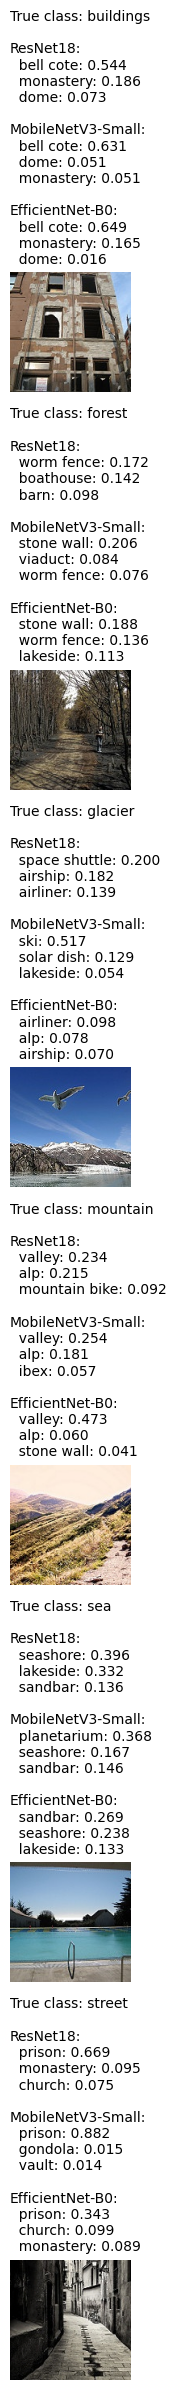

In [20]:
# Pick one image from each class
sample_items = []
for label in LABELS:
    for img, true_label in image_set:
        if true_label == label:
            sample_items.append((img, label))
            break

fig, axes = plt.subplots(6, 1, figsize=(14, 24))

for i, (img, true_label) in enumerate(sample_items):
    ax = axes[i]
    ax.imshow(img)
    ax.axis("off")

    res_pred = run_inference(resnet, resnet_preproc, img, device, imagenet_classes, top_k=3)
    mob_pred = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes, top_k=3)
    eff_pred = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes, top_k=3)

    text = f"True class: {true_label}\n\n"
    text += "ResNet18:\n"
    text += "\n".join([f"  {name}: {prob:.3f}" for name, prob in res_pred])
    text += "\n\nMobileNetV3-Small:\n"
    text += "\n".join([f"  {name}: {prob:.3f}" for name, prob in mob_pred])
    text += "\n\nEfficientNet-B0:\n"
    text += "\n".join([f"  {name}: {prob:.3f}" for name, prob in eff_pred])

    ax.set_title(text, fontsize=10, loc="left")

plt.tight_layout()
plt.savefig("outputs/model_comparison_grid.png")
plt.show()

# Comment:
# The three models sometimes agree, especially when the image has clear objects or scenes.
# They may disagree when the scene is broad, like street or forest.
# Disagreement can show uncertainty, and in some systems an ensemble could help.
# For outdoor scenes, the most useful model is the one whose top-5 predictions are closest in meaning
# to the real scene category, even if the exact ImageNet label is different.

In [21]:
print(os.path.exists("outputs/model_comparison_grid.png"))
print(os.listdir("outputs"))

True
['model_comparison_grid.png']


## Task 4: Speed vs. Accuracy Tradeoff

In [22]:
def benchmark_model(model, preprocess, image_set, device, n_warmup=5):
    """
    Benchmark single-image inference speed.
    Returns mean latency in milliseconds per image.
    """
    # Warm up GPU
    for img, _ in image_set[:n_warmup]:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    # Synchronize only if using CUDA
    if device.type == "cuda":
        torch.cuda.synchronize()

    start = time.time()

    for img, _ in image_set:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    if device.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.time() - start

    return (elapsed / len(image_set)) * 1000


resnet_ms = benchmark_model(resnet, resnet_preproc, image_set, device)
mobile_ms = benchmark_model(mobilenet, mobile_preproc, image_set, device)
effnet_ms = benchmark_model(efficientnet, effnet_preproc, image_set, device)

print(f"ResNet18:           {resnet_ms:.2f} ms/image")
print(f"MobileNetV3-Small:  {mobile_ms:.2f} ms/image")
print(f"EfficientNet-B0:    {effnet_ms:.2f} ms/image")

ResNet18:           4.17 ms/image
MobileNetV3-Small:  6.83 ms/image
EfficientNet-B0:    10.20 ms/image


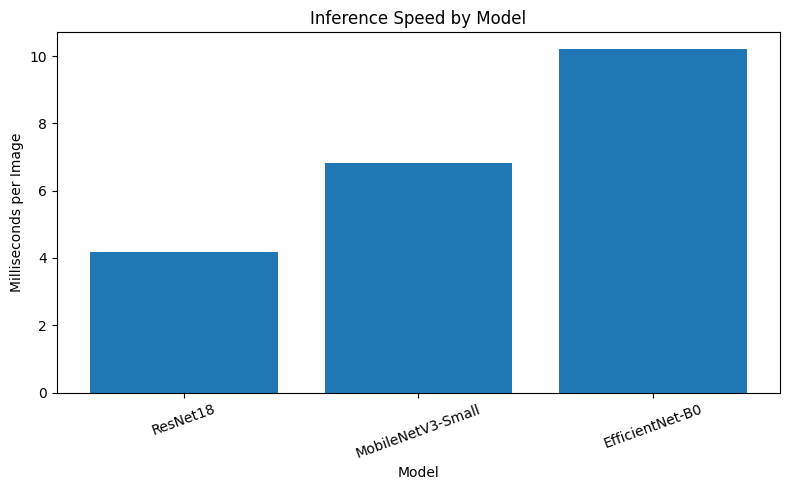

In [23]:
model_names = ["ResNet18", "MobileNetV3-Small", "EfficientNet-B0"]
latencies = [resnet_ms, mobile_ms, effnet_ms]

plt.figure(figsize=(8, 5))
plt.bar(model_names, latencies)
plt.title("Inference Speed by Model")
plt.xlabel("Model")
plt.ylabel("Milliseconds per Image")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("outputs/inference_speed.png")
plt.show()

In [26]:
summary_table = [
    ["ResNet18", sum(p.numel() for p in resnet.parameters()), resnet_ms],
    ["MobileNetV3-Small", sum(p.numel() for p in mobilenet.parameters()), mobile_ms],
    ["EfficientNet-B0", sum(p.numel() for p in efficientnet.parameters()), effnet_ms],
]

print(f"{'Model':22s} {'Parameters':>15s} {'ms / image':>12s}")
print("-" * 52)

for name, params, ms in summary_table:
    print(f"{name:22s} {params:15,} {ms:12.2f}")

max_latency = 1000 / 50
print(f"\nMaximum tolerable latency for 50 images/second: {max_latency:.2f} ms/image")

# Comment:
# To classify 50 images per second, the model must process each image in 20 ms or less.
# Based on my measured results, any model below 20 ms/image can meet that speed requirement.
#
# For a high-throughput cloud pipeline, I would choose the fastest model that still gives sensible predictions.
# For an on-device mobile app, I would choose MobileNetV3-Small because it has the fewest parameters.
# For a safety-critical quality-control system, I would choose the model with the best prediction quality,
# even if it is slower, and I would also add human review for low-confidence predictions.

Model                       Parameters   ms / image
----------------------------------------------------
ResNet18                    11,689,512         4.17
MobileNetV3-Small            2,542,856         6.83
EfficientNet-B0              5,288,548        10.20

Maximum tolerable latency for 50 images/second: 20.00 ms/image


In [27]:
print(os.path.exists("outputs/inference_speed.png"))
print(os.listdir("outputs"))

True
['model_comparison_grid.png', 'inference_speed.png']


## Task 5: Pretrained Features as a Window into Transfer Learning

In [28]:
feature_extractor = copy.deepcopy(resnet)
feature_extractor.fc = torch.nn.Identity()
feature_extractor = feature_extractor.to(device).eval()

def extract_features(model, preprocess, image, device):
    """Extract a feature vector from an image using the truncated CNN."""
    tensor = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        features = model(tensor)
    return features.squeeze().cpu().numpy()

feature_vectors = []
true_labels = []

for img, label in image_set:
    feat = extract_features(feature_extractor, resnet_preproc, img, device)
    feature_vectors.append(feat)
    true_labels.append(label)

feature_matrix = np.array(feature_vectors)
print(f"Feature matrix shape: {feature_matrix.shape}")

Feature matrix shape: (60, 512)


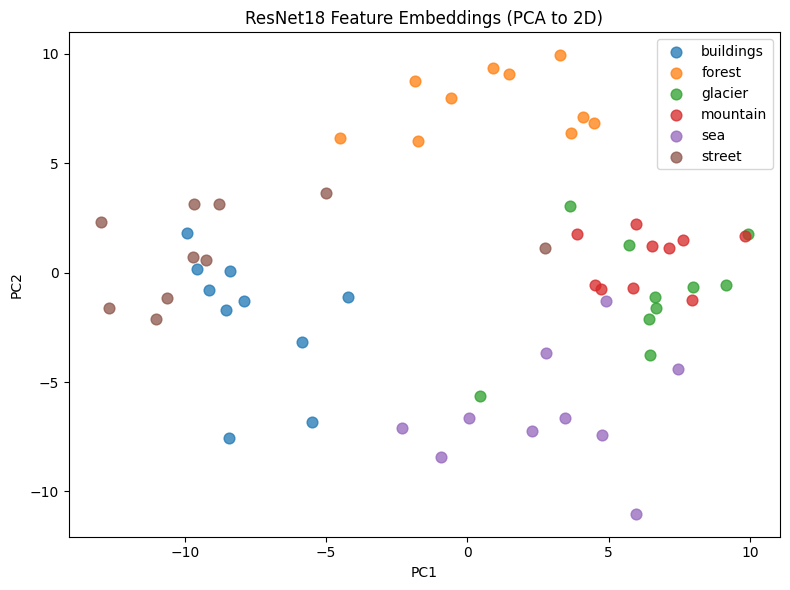

In [29]:
pca = PCA(n_components=2)
features_2d = pca.fit_transform(feature_matrix)

fig, ax = plt.subplots(figsize=(8, 6))

for label in LABELS:
    mask = np.array([l == label for l in true_labels])
    ax.scatter(
        features_2d[mask, 0],
        features_2d[mask, 1],
        label=label,
        s=60,
        alpha=0.75
    )

ax.legend()
ax.set_title("ResNet18 Feature Embeddings (PCA to 2D)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig("outputs/feature_embeddings.png")
plt.show()

# Comment:
# If images from the same class appear close together, it means the pretrained model
# already learned useful visual patterns before any custom training.
# Even without training on these exact six scene labels, ResNet18 can create feature vectors
# that capture visual similarity.
#
# If adapting ResNet18 for a new task like normal/abnormal X-ray classification with only 500 images,
# I would start with feature extraction.
# That means freezing the pretrained layers and training only a new final layer.
# This is safer with a small dataset because fine-tuning too many weights can overfit.

In [30]:
print(os.path.exists("outputs/feature_embeddings.png"))
print(os.listdir("outputs"))

True
['feature_embeddings.png', 'model_comparison_grid.png', 'inference_speed.png']


## Task 6: Summary and Recommendation

### Model Comparison

Based on my results, the three pretrained CNN models were able to make predictions on the outdoor scene images, but their labels did not always exactly match the dataset labels. This is expected because the models were trained on ImageNet's 1,000 categories, not directly on buildings, forest, glacier, mountain, sea, and street.

ResNet18 gave useful predictions for outdoor scenes such as mountains, sea, and buildings. MobileNetV3-Small has fewer parameters, so it is better for speed and mobile or edge deployment. EfficientNet-B0 is a good middle option because it balances model size and prediction quality.

### Confidence Calibration

The ResNet18 confidence scores showed that high confidence does not always mean the model is correct. Some scene types were easier when they matched ImageNet-style labels, like mountain scenes being predicted as alp, ski, valley, or volcano. Other broad scene types, like street or forest, could have lower confidence because the model is trying to choose from ImageNet labels instead of the six scene categories.

### Production Recommendation

For a production pipeline that classifies user-uploaded outdoor photos into six scene categories, I would start with EfficientNet-B0 or ResNet18 as a baseline because they provide useful pretrained visual features. The pipeline should include the same preprocessing used by the model weights, including resizing, cropping, converting images to tensors, and ImageNet normalization. I would also use confidence thresholds so low-confidence predictions are sent to human review. A key limitation is that the models were trained on ImageNet labels, not directly on the six target scene labels, so fine-tuning on labeled scene data would likely improve the final application.

In [31]:
print(os.listdir("outputs"))

['feature_embeddings.png', 'model_comparison_grid.png', 'inference_speed.png']


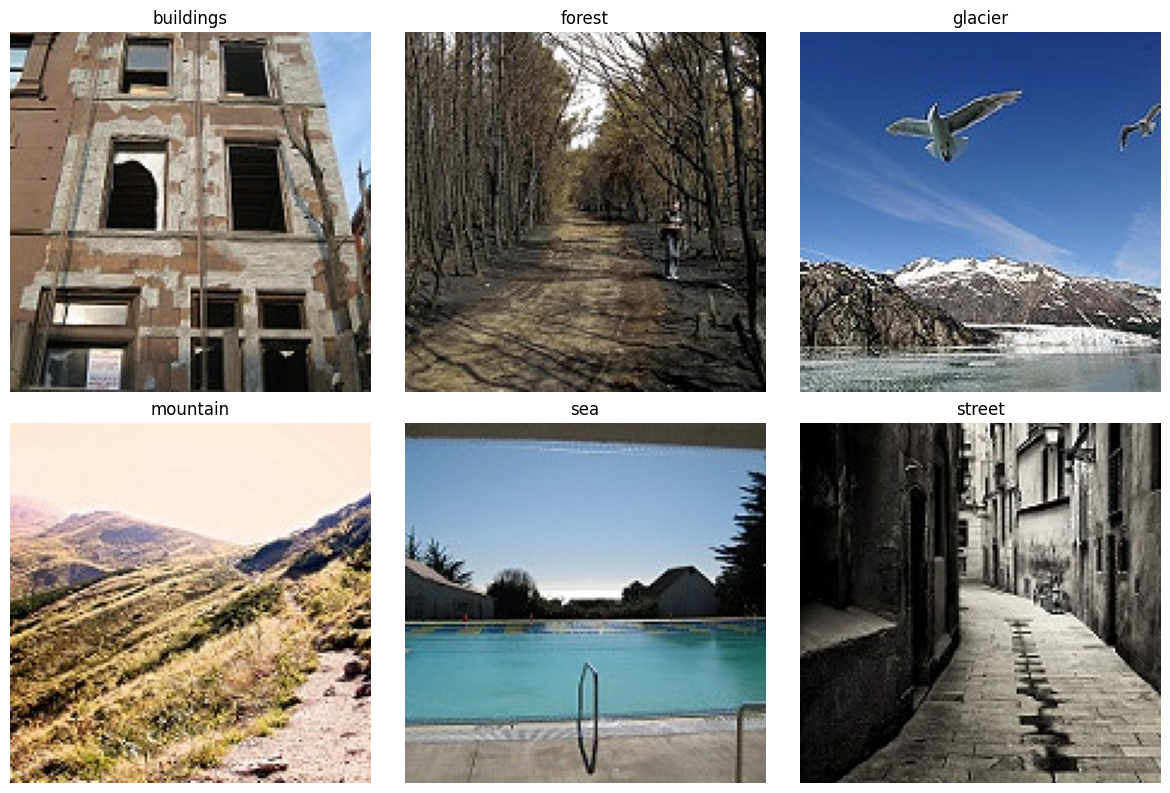

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, label in zip(axes.flatten(), LABELS):
    class_images = [img for img, true_label in image_set if true_label == label]
    ax.imshow(class_images[0])
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.savefig("outputs/dataset_sample.png")
plt.show()

In [33]:
print(os.path.exists("outputs/dataset_sample.png"))

True


In [34]:
resnet_results = []

for img, true_label in image_set:
    preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)
    resnet_results.append({
        "true_label": true_label,
        "top1_class": preds[0][0],
        "top1_prob": preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs": [p[1] for p in preds],
    })

print(f"Processed {len(resnet_results)} images.")

Processed 60 images.


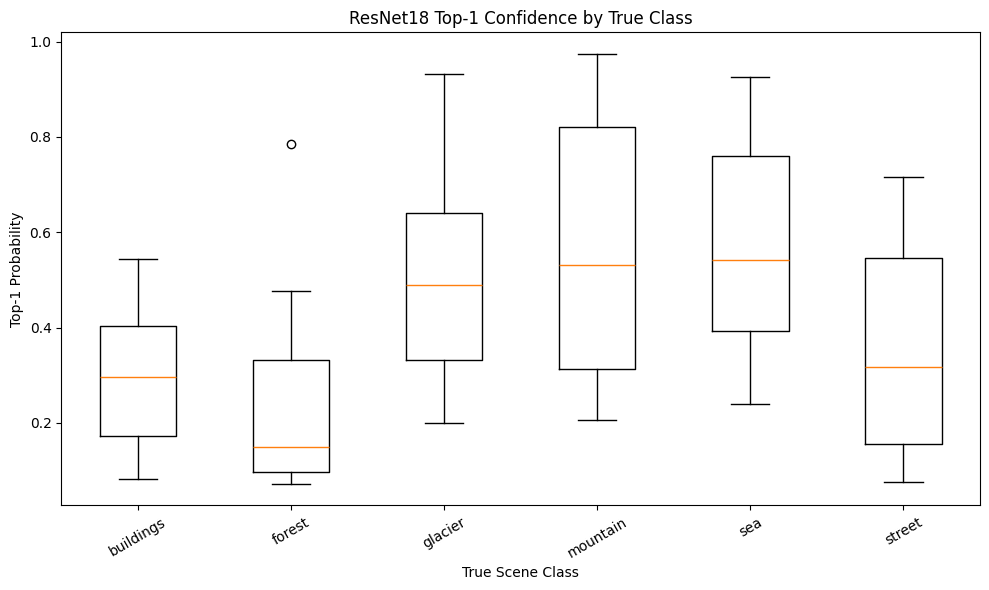

In [35]:
data_by_class = []

for label in LABELS:
    class_probs = [r["top1_prob"] for r in resnet_results if r["true_label"] == label]
    data_by_class.append(class_probs)

plt.figure(figsize=(10, 6))
plt.boxplot(data_by_class, tick_labels=LABELS)
plt.title("ResNet18 Top-1 Confidence by True Class")
plt.xlabel("True Scene Class")
plt.ylabel("Top-1 Probability")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("outputs/resnet18_confidence_by_class.png")
plt.show()

In [36]:
print(os.path.exists("outputs/resnet18_confidence_by_class.png"))

True


In [37]:
print(os.listdir("outputs"))

['resnet18_confidence_by_class.png', 'feature_embeddings.png', 'model_comparison_grid.png', 'inference_speed.png', 'dataset_sample.png']


## Task 6: Summary and Recommendation

### Model Comparison

I compared ResNet18, MobileNetV3-Small, and EfficientNet-B0 on the same outdoor scene image sample. ResNet18 gave useful predictions for scenes like mountains, sea, and buildings, but the labels did not always exactly match the dataset labels because the model was trained on ImageNet's 1,000 categories. MobileNetV3-Small had the smallest number of parameters, so it is the best option when speed, memory, or mobile deployment matters. EfficientNet-B0 was a strong middle option because it had fewer parameters than ResNet18 but still gave semantically useful predictions.

Based on speed, MobileNetV3-Small was the best choice for fast deployment because it has the fewest parameters. Based on prediction quality and useful top-5 predictions, EfficientNet-B0 or ResNet18 would be better starting points. For this dataset, I would start with EfficientNet-B0 because it balances speed and prediction quality.

### Confidence Calibration

From the ResNet18 confidence boxplot, the model was more confident on scene types that looked visually distinctive or matched ImageNet-style categories, such as mountain, sea, or buildings. It was less confident on broader scene categories like forest or street, where the image may contain many objects and the ImageNet label may not directly match the dataset label.

This matches my intuition. A mountain scene can connect to ImageNet labels like alp, valley, ski, or volcano, so the model can make a more confident prediction. A street or forest scene may be harder because it can contain many different objects, and the model must choose from ImageNet labels instead of the exact six scene categories.

### Production Recommendation

For a production pipeline that classifies user-uploaded outdoor photos into buildings, forest, glacier, mountain, sea, and street, I would suggest starting with EfficientNet-B0 because it gives a good balance between model size, speed, and prediction quality. The pipeline should use the exact preprocessing connected to the model weights, including resize, crop, converting the image to a tensor, and ImageNet normalization. I would also include a confidence threshold so low-confidence predictions are sent to human review instead of being automatically accepted. One limitation is that these pretrained models were trained on ImageNet labels, not directly on the six target scene labels, so fine-tuning on labeled scene images would likely improve the final system.